## Imports

In [160]:
import torch
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn

## Check Device

In [161]:
# backends.cuda, backends.mps, backends.mkl (intel cpu math library), backends.cudnn (NVIDIA's deep learning primitive)

if torch.backends.mps.is_available():   # metal performance shaders (apple's GPU)
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

## Visualization

In [162]:
print(f"Using device: {device}")

Using device: mps


In [163]:
# compose chains multiple image transforms into a single callable pipeline
# For visualization, we only use ToTensor(), we don't use normalization
# pytorch expects channels first,ToTensor() helps to:
#   1) convert the PIL image or Numpy array from (H,W,C) to (C,H,W)
#   2) rescale pixel values from (0,255) to [0.0,1.0] floats


train_transform_viz = transforms.Compose([transforms.ToTensor(),
                                        transforms.Resize((224, 224))])

In [164]:
# Loads the CIFAR-10 dataset
# root means where to save the file
# train means load the training split (already pre split), download if data is not fouund in root
# use the transform created in the cell above

train_viz = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=train_transform_viz)

In [165]:
# DataLoader wraps a dataset and handles feeding it to the model in batches
# takes in the dataset, batch_size, and randomly shuffle the data every epoch
# some other arguments used: num_workers=4 (for parallel workers)
# pin_memory=True (faster CPU to GPU transfer)
# drop_last=True (drop final batch if len(dataset) % batch_size != 0)

train_viz_loader = torch.utils.data.DataLoader(train_viz, batch_size=32, shuffle=True)

In [166]:
# converts the DataLoader into a python iterator - an object you can call next() on to pull one batch at a time
data_iter = iter(train_viz_loader)

# Pulls out the first randomized batch out of the iterator
images, labels = next(data_iter)

In [167]:
images.shape

torch.Size([32, 3, 224, 224])

In [168]:
labels.shape

torch.Size([32])

*``iter`` and ``next`` can be used to test if the model and training works:*

- ``output = model(images)``

- ``print(output.shape)  # does the model work?``

In [169]:
grid = torchvision.utils.make_grid(images)

In [170]:
images_grid = grid.permute(1,2,0)

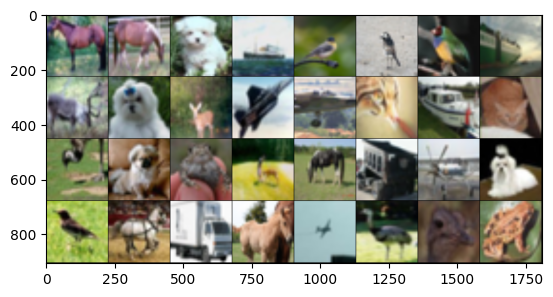

In [171]:
plt.imshow(images_grid)

## Data Augmentation

In [172]:
train_transform = transforms.Compose([  transforms.Resize((224, 224)),
                                        transforms.RandomHorizontalFlip(),              # randomly mirrors the image (horizontally) with 50% chance
                                        transforms.RandomCrop(224, padding=4),           # pads the image by 4 black pixels on each side, then randomly crop back to 32*32
                                        transforms.ToTensor(),                          # same thing as before, PIL/Numpy (H,W,C) uint8 --> (C,H,W) float in [0.0, 0.1]
                                        transforms.Normalize((0.4914, 0.4822, 0.4465), 
                                                            (0.2023, 0.1994, 0.2010))
                                    ])
# Normalize are pre-computed statistics from the entire CIFAR-10 training set, one per RGB channel (standard one)

In [173]:
test_transform = transforms.Compose([   transforms.Resize((224, 224)),
                                        transforms.ToTensor(),
                                        transforms.Normalize((0.4914, 0.4822, 0.4465),
                                                            (0.2023, 0.1994, 0.2010))
                                    ])

In [174]:
train = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=train_transform)
test = torchvision.datasets.CIFAR10(root='../../data', train=False, download=True, transform=test_transform)
val = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=train_transform)

In [175]:
# _ is just a placeholder
# unfortunately, this does not ensure that there are no overlaps between train and val

train, _ = torch.utils.data.random_split(train, [0.8, 0.2])
_, val  = torch.utils.data.random_split(val, [0.8, 0.2])

## Training

In [176]:
from model import VGG

save_path = '../../models/vgg/model.pth'
best_val_accuracy = 0
patience = 5
epochs_without_improvements = 0
total_epochs = 100
model = VGG().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, min_lr=1e-5)

for epoch in range(total_epochs):

    # ------------- TRAINING ------------------
    model.train()
    for images, labels in tqdm(train_loader):
        optimizer.zero_grad()
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # ------------- EVALUATION -----------------
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)                 # forward pass through current model with weights, output 10 scores per image
            _, predicted = torch.max(outputs, 1)    # torch.max() gives class with highest score (gives actual score and our prediction)
                                                    # we don't care about actual score, thats's why we save it as a placeholder _
            total += labels.size(0)                 # labels is 1D tensor (32,) meaning 32 images in a batch, 1 label per batch
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    scheduler.step(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        epochs_without_improvements = 0
        torch.save(model.state_dict(), save_path)
    else:
        epochs_without_improvements += 1

    if epochs_without_improvements >= patience:
        print(f"Early stopping at epoch {epoch+1}")
    
    print(f"Epoch {epoch+1}/{total_epochs}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy:.2f}%, LR: {optimizer.param_groups[0]['lr']:.6f}")


100%|██████████| 1250/1250 [52:22<00:00,  2.51s/it]


Epoch 1/100, Loss: 2.3019, Val Accuracy: 10.03%, LR: 0.001000


100%|██████████| 1250/1250 [2:26:53<00:00,  7.05s/it]   


Epoch 2/100, Loss: 2.3071, Val Accuracy: 9.82%, LR: 0.001000


100%|██████████| 1250/1250 [53:55<00:00,  2.59s/it]


Epoch 3/100, Loss: 2.3143, Val Accuracy: 10.04%, LR: 0.001000


100%|██████████| 1250/1250 [3:42:56<00:00, 10.70s/it]   


Epoch 4/100, Loss: 2.3030, Val Accuracy: 9.95%, LR: 0.001000


  8%|▊         | 101/1250 [03:29<39:47,  2.08s/it]


KeyboardInterrupt: 

In [ ]:
# load best model and test
model.load_state_dict(torch.load(save_path))
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

KeyboardInterrupt: 

In [177]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
            'dog', 'frog', 'horse', 'ship', 'truck']

all_predictions = []
all_labels = []

model.load_state_dict(torch.load('../../models/vgg/model.pth'))
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)                                    # gets the class with highest score for each image, throws away actual score value, predicted keeps the class index
        all_predictions.extend(predicted.cpu().numpy())                         # .cpu() moves tensors from MPS to CPU memory, sklearn can't read from GPU, .numpy means we then convert it to numpy
        all_labels.extend(labels.cpu().numpy())                                 # extend just adds all the items from the batch into the list one by one

cm = confusion_matrix(all_labels, all_predictions)                              # sklearn takes the true labels and predictions and builds a 10x10 matrix counting how many times each true class got predicted as each class
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)      # wraps the raw matrix in display settings, attaches the class names
disp.plot(xticks_rotation=45)                                                   # rotates the x axis labels so they don't overlap
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 